# LOAD LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet
import os
import sys
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.config import PERIOD_START, PERIOD_END, select_period
from src.gapfilling_utils import (
    setup_log_transform,
    undersample_target,
    learn_gap_dist,
    create_artificial_gap_splits,
    plot_cv_splits,
    rfe_selection
)

# CONFIGURATION

In [2]:
START_DATE, END_DATE = PERIOD_START, PERIOD_END  # dataset period, see src/config.py
TARGET_FLUX = 'FN2O'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
N_FOLDS = 10
PARCEL_CERTAIN = True # choose if to use in the training also values coming from mixed contribution
LOG_TRANSFORM = False
UNDERSAMPLE = False
ADD_ID = True
ADD_TRT = True
ADD_CANOPY = False

# LOAD DATA

In [3]:
data_main = fluxes = load_parquet(filepath=r"82.1.1_GapFillingDataset.parquet")
data_main = select_period(data_main, timestamp='middle')
print(f"\nUsing data from {START_DATE} to {END_DATE}")
TARGET = f"{TARGET_FLUX}_L3.3_CUT_50_QCF0"
print(f"\nTarget column: {TARGET}")

data_main

Loaded .parquet file 82.1.1_GapFillingDataset.parquet (0.083 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
select_period: kept 13776 of 13776 records (2024-08-22 00:15:00 to 2025-06-04 23:45:00, timestamp=middle)

Using data from 2024-08-22 00:00:00 to 2025-06-05 00:00:00

Target column: FN2O_L3.3_CUT_50_QCF0


,NEE_L3.3_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,FN2O_L3.3_CUT_16_QCF,FN2O_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_84_QCF,FN2O_L3.3_CUT_16_QCF0,FN2O_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FN2O_RANDUNC_HF,SW_IN_POT,prec,ta,...,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,can_height,cropN,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-08-22 00:15:00,4.791627,0.475098,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,0.461859,0.0,0.000,11.276667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,0
2024-08-22 00:45:00,4.565958,0.662601,0.365031,0.365031,NaN,NaN,NaN,NaN,A,certain,0.0,0.779504,0.0,0.000,11.043333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,1
2024-08-22 01:15:00,4.673149,0.530312,NaN,NaN,NaN,NaN,NaN,NaN,B,uncertain,1.0,0.107261,0.0,0.000,10.890000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,2
2024-08-22 01:45:00,4.323735,0.851883,1.399927,NaN,NaN,1.399927,NaN,NaN,A,certain,0.0,0.457078,0.0,0.000,10.720000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,3
2024-08-22 02:15:00,4.323735,0.868263,NaN,NaN,NaN,NaN,NaN,NaN,A,certain,0.0,0.560318,0.0,0.000,10.820000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,10.578562,-0.970199,0.524032,0.524032,0.524032,0.524032,0.524032,0.524032,B,certain,1.0,0.226180,0.0,0.017,15.693333,...,0.205000,0.318334,-0.270000,-0.042154,-0.862990,-1.240195,-0.138894,-0.501428,-0.865616,-0.130630,-0.951387,-1.460515,39.079782,NaN,13771
2025-06-04 22:15:00,9.416519,0.146401,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,0.249031,0.0,0.034,15.516667,...,0.199444,0.353332,-0.281666,0.030612,-0.850980,-1.201306,-0.115306,-0.455520,-0.859899,-0.075635,-0.878298,-1.447001,39.111514,NaN,13772
2025-06-04 22:45:00,10.095010,-0.495217,-0.069384,-0.069384,-0.069384,-0.069384,-0.069384,-0.069384,B,certain,1.0,0.279950,0.0,0.425,15.660000,...,0.098889,0.368333,-0.310000,0.025945,-0.847119,-1.197830,-0.108815,-0.438437,-0.860283,-0.205865,-0.852473,-1.503494,39.143246,NaN,13773


# CLEAN DATA

In [4]:
# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Remove data with mixed attribution if PARCEL_CERTAIN==True
if PARCEL_CERTAIN:
    before = len(data)
    data = data.loc[data["parcel_certainty"].eq("certain")].copy()
    print(f"Filtered parcel_certainty=='certain': {len(data)}/{before} rows kept")
else:
    print("Using all data regardless of parcel_certainty (mixed contribution allowed)")

# Remove teatment variable if ADD_TRT==False
if ADD_TRT==False:
    data.drop(columns='trt', inplace=True)
    print('\nRemoved the treatment variable (trt)')
else:
    print('\nKeeping the treatment variable (trt)')

# Remove id variable if ADD_ID==False
if ADD_ID==False:
    data.drop(columns='id', inplace=True)
    print('\nRemoved the record number variable (id)')
else:
    print('\nKeeping the record number variable (id)')

# Remove canopy variables if ADD_CANOPY==False
if ADD_CANOPY==False:
    prefix = ('LAI', 'can_height', 'cropN')
    to_drop = [c for c in data.columns if c.startswith(prefix)]
    data.drop(columns=to_drop, inplace=True)
    print(f"\nDropped {len(to_drop)} canopy columns: {to_drop}")

# Drop variables related to specific parcels
to_drop = [c for c in data.columns if 'parcel' in c]
data.drop(columns=to_drop, inplace=True)
print(f"\nDropped {len(to_drop)} parcel-specific columns: {to_drop}")

# keep numeric only (feature selection models require numeric)
data = data.select_dtypes(include=[np.number]).copy()

# Remove any flux variable with TARGET_FLUX except for the target itself
to_drop = [c for c in data.columns if (TARGET_FLUX in c and c != TARGET)]
data.drop(columns=to_drop, inplace=True)

# Remove feature columns with too many missing values where target is not missing
drop_missing = [
    c for c in data.columns
    if c != TARGET and data[c].isna().mean() > 0.05
]
data.drop(columns=drop_missing, inplace=True)
print(f"Dropped {len(drop_missing)} high-missing features (>5% NA) where target is not missing: {drop_missing}")

# Build complete-case training set
feature_cols = [c for c in data.columns if c != TARGET]
train_mask = data[TARGET].notna() & data[feature_cols].notna().all(axis=1)
df_train = data.loc[train_mask, feature_cols + [TARGET]].copy()
print(f"Training rows (complete-case): {len(df_train)}/{len(data)}")

X = df_train[feature_cols]
y = df_train[TARGET].astype(float)

df_train

Filtered parcel_certainty=='certain': 4668/5292 rows kept

Keeping the treatment variable (trt)

Keeping the record number variable (id)

Dropped 6 canopy columns: ['can_height_parcelA', 'can_height_parcelB', 'cropN_parcelA', 'cropN_parcelB', 'can_height', 'cropN']

Dropped 2 parcel-specific columns: ['parcel', 'parcel_certainty']
Dropped 0 high-missing features (>5% NA) where target is not missing: []
Training rows (complete-case): 4647/4668


,NEE_L3.3_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,trt,SW_IN_POT,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,n_decay_linear,n_decay_logistic,...,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,id,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-08-23 01:15:00,9.276028,-3.644258,1.0,0.0000,0.000,13.520000,34.0,18.768888,20.383703,19.819257,24.434128,43.257080,42.078620,183.150794,187.234814,...,0.314074,0.014443,0.819257,-0.217038,-0.850289,-2.860096,-4.070174,-0.163694,-0.625207,-1.423900,0.035018,-0.187479,-0.454791,50,0.914373
2024-08-23 08:45:00,2.910790,3.949205,1.0,737.1340,0.000,21.276667,3.0,17.737037,18.800000,19.200000,23.868266,42.825938,41.956511,180.353175,187.111566,...,0.400000,-0.514073,-0.728146,0.000000,-0.402791,-1.157447,-3.878234,-0.325283,-0.512421,-1.579345,-0.111596,-0.111718,-0.429980,65,0.645681
2024-08-23 09:15:00,3.440897,3.572392,1.0,824.6200,0.000,22.273333,4.0,17.937037,18.800000,19.115927,23.922998,42.727796,41.982599,180.166667,187.102680,...,0.400000,-0.575926,-0.877037,-0.031111,-0.261990,-1.065792,-3.842420,-0.408873,-0.650193,-1.642006,-0.077859,-0.105344,-0.426255,66,1.161912
2024-08-23 10:15:00,5.128562,2.097636,1.0,965.9900,0.000,23.670000,6.0,18.648148,18.898518,19.083704,23.875095,42.490053,41.915091,179.793651,187.084641,...,0.498518,-0.517407,-0.916296,0.032963,-0.205629,-0.943972,-4.013500,-0.627314,-0.844707,-1.740525,-0.071097,-0.169986,-0.531700,68,0.649394
2024-08-23 10:45:00,-0.720471,8.041460,1.0,1017.4600,0.000,24.296667,7.0,19.283704,18.967407,19.007036,23.784665,42.349932,41.880115,179.607143,187.075487,...,0.468148,-0.559630,-0.992964,0.007036,-0.213872,-0.962658,-4.100672,-0.807199,-0.952021,-1.838420,-0.114200,-0.195282,-0.545745,69,1.003027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 19:45:00,7.142296,2.619212,1.0,55.4533,0.017,16.290000,0.0,19.144444,18.900000,17.299444,47.839744,49.777009,45.348014,0.000000,0.000000,...,-0.962222,0.318334,0.208334,-0.193333,-0.394737,-0.852735,-1.385699,-0.185600,-0.503506,-0.912185,-0.167325,-0.959742,-1.349723,13767,0.553921
2025-06-04 20:45:00,10.168117,-0.510074,1.0,0.0000,0.017,15.886667,0.0,18.625556,18.723889,17.300000,47.851752,49.730719,45.234460,0.000000,0.000000,...,-0.993889,0.300000,0.300000,-0.201111,-0.193212,-0.844622,-1.290895,-0.200862,-0.530309,-0.928129,-0.159913,-0.976200,-1.424850,13769,-0.118021
2025-06-04 21:15:00,10.359786,-0.727433,1.0,0.0000,0.017,15.786667,0.0,18.385555,18.675556,17.300000,47.843403,49.728310,45.197942,0.000000,0.000000,...,-0.947778,0.284444,0.305001,-0.229445,-0.121255,-0.853115,-1.277483,-0.177867,-0.529632,-0.893077,-0.144427,-0.967252,-1.448612,13770,0.282174


# IMBALANCE HANDLING

## UNDER SAMPLING

In [5]:
if UNDERSAMPLE:
    df_train2, cutoff_value = undersample_target(
        df_train, TARGET,
        quantile_cutoff=0.8,
        fraction=0.5,
        random_state=42,
        verbose=True,
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
else:
    print("Undersampling not applied.")

Undersampling not applied.


## LOG TRANSFORMATION

In [6]:
if LOG_TRANSFORM:
    log_fn, inv_fn, min_value, df_train2 = setup_log_transform(
        df_train, TARGET, apply=True, plot=True, bins=20
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
    print(f"Applied log1p transform (shift={min_value if min_value < 0 else 0.0:.4g}).")
else:
    inv_fn = None
    print("Log transform not applied.")


Log transform not applied.


# CROSS-VAL SPLITS

  Gap distribution: fitted mixture (cvm distance 25.6617; raw baseline 30.6735)
CV Strategy: artificial gaps in real time; 10 splits; test fractions 0.098-0.106
  Coverage: 1647/4647 rows never held out (35.4%); mean times held out 1.01


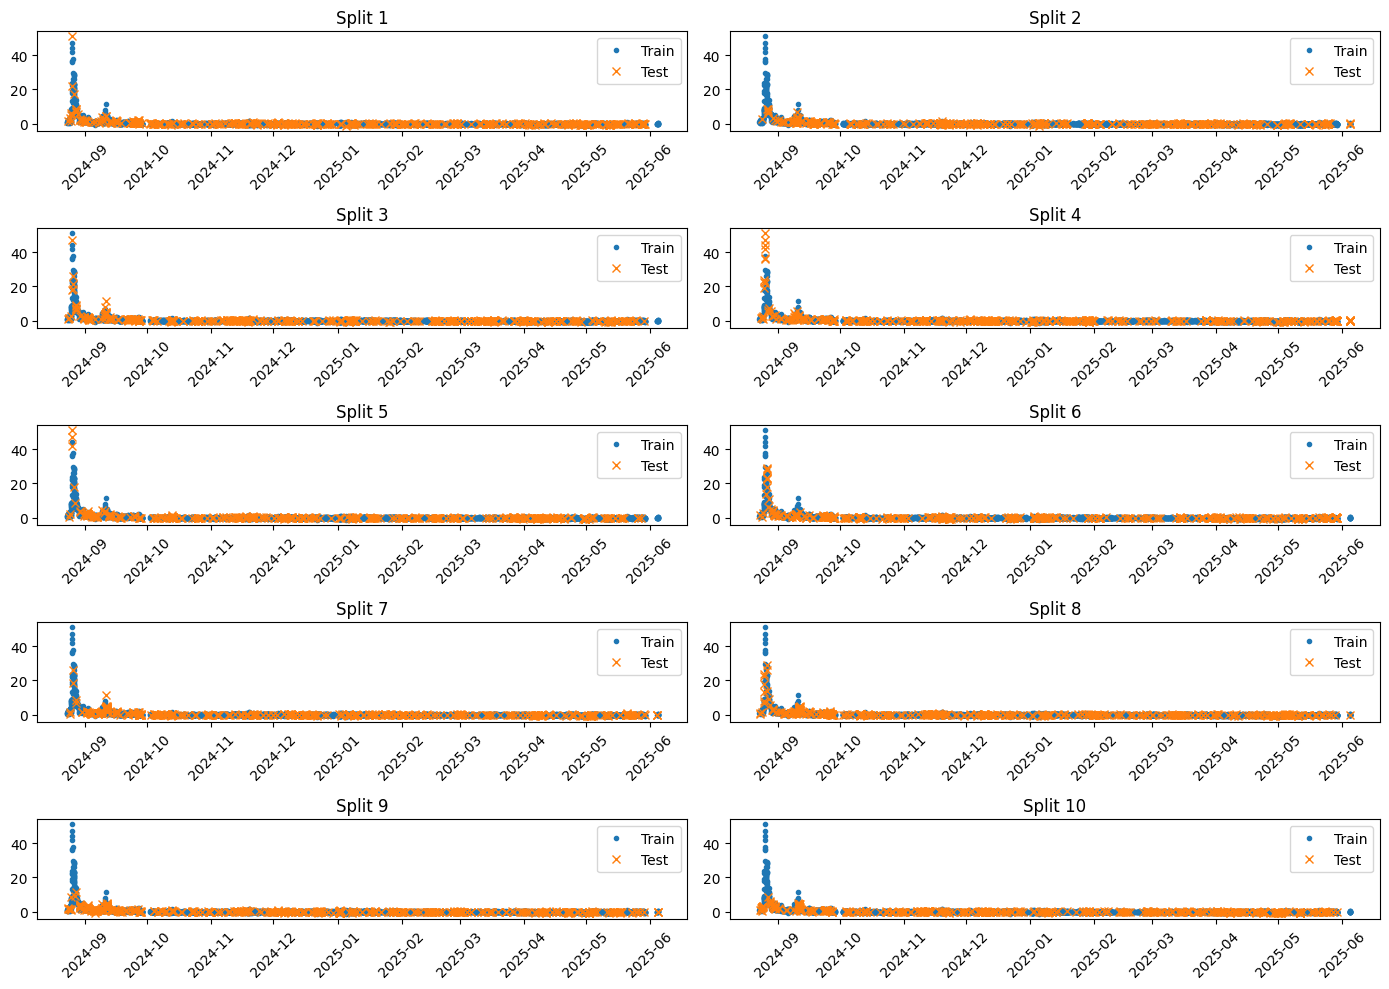

In [7]:
# Artificial-gap CV splits (Irvin et al. 2021 style)
rng = np.random.default_rng(42)

sampling_pmf = learn_gap_dist(data_main[TARGET], n_grid=6, n_mc=20, rng=rng, verbose=True)

splits, coverage = create_artificial_gap_splits(
    target_full=data_main[TARGET],   # full series, real NaNs intact -- NOT X/y
    train_index=X.index,
    sampling_pmf=sampling_pmf,
    n_splits=N_FOLDS,
    eval_frac=0.1,
    rng=rng,
    verbose=True,
)

# optional diagnostic plot
plot_cv_splits(X, y, splits, ncols=2);


# FEATURE SELECTION

In [8]:
# Model factory
def model_factory():
    if MODEL_TYPE == "RandomForest":
        return RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        )
    elif MODEL_TYPE == "XGBoost":
        return XGBRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        )
    else:
        raise ValueError("MODEL_TYPE must be 'RandomForest' or 'XGBoost'")

model_factory()

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

Iter 1: kept=153 removed=['timesince_fert_org', 'timesince_fert_min', 'timesince_fert', 'wfps_0.15_gfXG_lag9h_roll6hmean', 'prec_lag6h', 'ts_0.05_gfXG_lag3h_roll3hmean', 'prec_lag9h_roll3hsum', 'prec_lag9h', 'n_decay_timed', 'prec_lag3h'] RMSE_cv=0.7596 R2_cv=0.9073


Iter 2: kept=143 removed=['ts_0.3_gfXG_lag6h_roll3hmean', 'n_decay_logistic', 'prec_lag6h_roll6hsum', 'ts_0.3_gfXG_lag9h_roll6hmean', 'ts_0.05_gfXG_diff12h', 'ta_lag6h_roll9hmean', 'ts_0.15_gfXG_diff6h', 'timesince_harvest', 'wfps_0.3_gfXG_lag6h_roll6hmean', 'prec_roll6hsum'] RMSE_cv=0.7595 R2_cv=0.9071


Iter 3: kept=133 removed=['ts_0.3_gfXG_lag6h', 'wfps_0.3_gfXG_lag6h_roll3hmean', 'prec_lag3h_roll3hsum', 'SW_IN_POT', 'ts_0.3_gfXG_lag6h_roll9hmean', 'prec_lag3h_roll9hsum', 'ts_0.3_gfXG_diff12h', 'wfps_0.15_gfXG_diff12h', 'prec_roll9hsum', 'ts_0.05_gfXG_lag9h_roll9hmean'] RMSE_cv=0.7596 R2_cv=0.9053


Iter 4: kept=123 removed=['wfps_0.15_gfXG_lag3h_roll3hmean', 'wfps_0.15_gfXG_roll3hmean', 'ta_roll3hmean', 'ts_0.05_gfXG_diff24h', 'ta_roll6hmean', 'NEE_L3.3_CUT_50_QCF_footprint_gfXGBoost', 'wfps_0.3_gfXG_roll3hmean', 'ts_0.3_gfXG_lag6h_roll6hmean', 'wfps_0.15_gfXG_lag3h', 'wfps_0.05_gfXG_roll6hmean'] RMSE_cv=0.7420 R2_cv=0.9092


Iter 5: kept=113 removed=['ts_0.15_gfXG_lag6h_roll9hmean', 'ts_0.05_gfXG_lag3h_roll6hmean', 'ts_0.15_gfXG_lag3h', 'ta_lag9h_roll6hmean', 'ts_0.15_gfXG_lag9h_roll3hmean', 'prec', 'ts_0.15_gfXG_roll9hmean', 'prec_lag6h_roll3hsum', 'wfps_0.3_gfXG_lag3h', 'ts_0.15_gfXG_diff12h'] RMSE_cv=0.7721 R2_cv=0.9058


...

Iter 12: kept=43 removed=['ta_lag6h_roll6hmean', 'ts_0.3_gfXG_lag3h_roll9hmean', 'ta_lag6h', 'ts_0.3_gfXG_lag9h', 'wfps_0.05_gfXG_diff6h', 'ts_0.15_gfXG_lag9h_roll9hmean', 'wfps_0.05_gfXG_diff24h', 'wfps_0.3_gfXG_lag9h_roll9hmean', 'ts_0.05_gfXG_roll6hmean', 'wfps_0.3_gfXG_diff6h'] RMSE_cv=0.7539 R2_cv=0.9056


Iter 13: kept=33 removed=['wfps_0.15_gfXG_lag6h_roll9hmean', 'ts_0.3_gfXG_roll9hmean', 'ts_0.15_gfXG_lag6h', 'wfps_0.15_gfXG_lag6h', 'ts_0.05_gfXG_lag9h_roll3hmean', 'ts_0.3_gfXG_lag3h_roll3hmean', 'ts_0.3_gfXG_roll3hmean', 'prec_lag6h_roll9hsum', 'ts_0.05_gfXG_lag3h', 'ts_0.05_gfXG_diff6h'] RMSE_cv=0.7617 R2_cv=0.9099


Iter 14: kept=23 removed=['ts_0.15_gfXG_lag9h', 'wfps_0.05_gfXG_lag9h_roll6hmean', 'ts_0.3_gfXG_lag9h_roll3hmean', 'ts_0.15_gfXG_lag3h_roll6hmean', 'wfps_0.3_gfXG_diff24h', 'ts_0.05_gfXG_lag6h_roll6hmean', 'prec_lag9h_roll9hsum', 'ts_0.3_gfXG_diff24h', 'wfps_0.15_gfXG_diff6h', 'wfps_0.15_gfXG_lag9h_roll9hmean'] RMSE_cv=0.7490 R2_cv=0.9102


Iter 15: kept=13 removed=['wfps_0.05_gfXG_lag6h_roll3hmean', 'wfps_0.05_gfXG_lag9h_roll9hmean', 'wfps_0.15_gfXG_lag6h_roll3hmean', 'ts_0.3_gfXG_lag3h', 'wfps_0.05_gfXG_roll3hmean', 'wfps_0.15_gfXG_lag3h_roll6hmean', 'wfps_0.05_gfXG_lag9h_roll3hmean', 'timesince_soil_preparation', 'wfps_0.15_gfXG_roll9hmean', 'ta_lag3h_roll3hmean'] RMSE_cv=0.7693 R2_cv=0.9097


Iter 16: kept=10 removed=['wfps_0.05_gfXG_lag3h', 'wfps_0.15_gfXG_lag9h', 'n_decay_exponential'] RMSE_cv=0.7391 R2_cv=0.9123

Best features selected:
['n_decay_linear', 'n_decay_exponential', 'n_decay_lognormal', 'timesince_sowing', 'wfps_0.05_gfXG_lag3h', 'wfps_0.05_gfXG_lag9h', 'wfps_0.15_gfXG_lag9h', 'wfps_0.05_gfXG_lag3h_roll9hmean', 'wfps_0.05_gfXG_lag6h_roll6hmean', 'wfps_0.15_gfXG_lag3h_roll9hmean', 'wfps_0.15_gfXG_lag6h_roll6hmean', 'wfps_0.15_gfXG_lag9h_roll3hmean', 'id']

Feature ranking:
['n_decay_linear', 'n_decay_lognormal', 'timesince_sowing', 'wfps_0.05_gfXG_lag9h', 'wfps_0.05_gfXG_lag3h_roll9hmean', 'wfps_0.05_gfXG_lag6h_roll6hmean', 'wfps_0.15_gfXG_lag3h_roll9hmean', 'wfps_0.15_gfXG_lag6h_roll6hmean', 'wfps_0.15_gfXG_lag9h_roll3hmean', 'id', 'wfps_0.05_gfXG_lag3h', 'wfps_0.15_gfXG_lag9h', 'n_decay_exponential', 'wfps_0.05_gfXG_lag6h_roll3hmean', 'wfps_0.05_gfXG_lag9h_roll9hmean', 'wfps_0.15_gfXG_lag6h_roll3hmean', 'ts_0.3_gfXG_lag3h', 'wfps_0.05_gfXG_roll3hmean', 'wfps

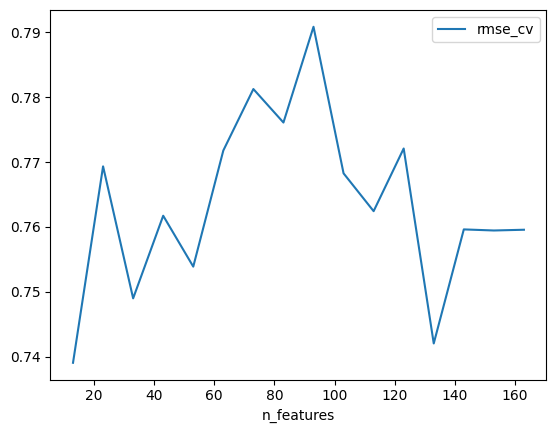

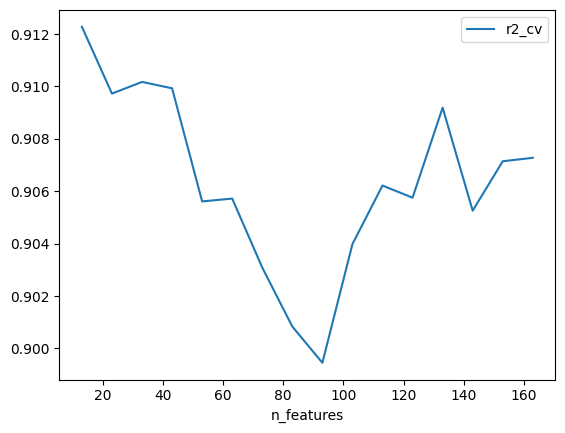

In [9]:
best_feats, ranking, hist = rfe_selection(
    X, y, splits,
    model_factory=model_factory,
    inv_y=inv_fn if LOG_TRANSFORM else None,
    step=10,           # try 5 or 10 if it’s slow
    min_features=10,
    verbose=True,
    score_mode='composite',  # 'rmse' or 'composite',
    w_penalty = 0.001
)

hist.plot(x="n_features", y="rmse_cv");
hist.plot(x="n_features", y="r2_cv");

print(f"\nBest features selected:\n{best_feats}")
print(f"\nFeature ranking:\n{ranking}")


# EXPORT 

In [10]:
filename = f"best_features_{TARGET_FLUX}_{MODEL_TYPE}.txt"
with open(filename, "w") as f:
    for item in best_feats:
        f.write(f"{item}\n")
print("Wrote:", filename)

filename = f"ranked_features_{TARGET_FLUX}_{MODEL_TYPE}.txt"
with open(filename, "w") as f:
    for item in ranking:
        f.write(f"{item}\n")
print("Wrote:", filename)


Wrote: best_features_FN2O_XGBoost.txt
Wrote: ranked_features_FN2O_XGBoost.txt


# **End of notebook**

In [11]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-10-06 16:43:07
